#  Fraud Detection Pipeline: 


## Step 1: Import Libraries and Load Data
First, we need to bring in our toolbox. We'll be using:
- **Pandas & Numpy**: For data manipulation.
- **Matplotlib & Seaborn**: For drawing beautiful graphs.
- **Scikit-Learn (sklearn)**: Our main machine learning library to build models and evaluate them.
- **Imbalanced-Learn (imblearn)**: A special library designed to help us handle that tricky class imbalance we talked about.

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning components
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Let's ignore some annoying warnings to keep our notebook clean
import warnings
warnings.filterwarnings('ignore')

Now let's load our data using pandas and take a quick peek at the first 5 rows.

In [2]:
# Load the dataset from a CSV file
df = pd.read_csv('credit_card_fraud_10k.csv')

# display() looks a bit nicer than print() in Jupyter Notebooks
display(df.head())

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


###  Analyzing the Class Imbalance
Let's see exactly how imbalanced our dataset is by counting the `is_fraud` column (where `0` means Normal, and `1` means Fraud).

In [3]:
# Count the exact number of normal vs fraudulent transactions
fraud_count = df['is_fraud'].value_counts()

# Calculate the percentage
fraud_percentage = df['is_fraud'].value_counts(normalize=True) * 100

print("Transaction Counts:\n", fraud_count)
print("\nPercentage Breakdown:\n", round(fraud_percentage, 2))

Transaction Counts:
 is_fraud
0    9849
1     151
Name: count, dtype: int64

Percentage Breakdown:
 is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


## Step 2: Exploratory Data Analysis (EDA)
Before throwing data into an AI model, it's essential to understand the patterns. Let's ask two questions:
1. *Do fraudsters spend different amounts of money than normal people?*
2. *Do frauds happen at different times of the day?*

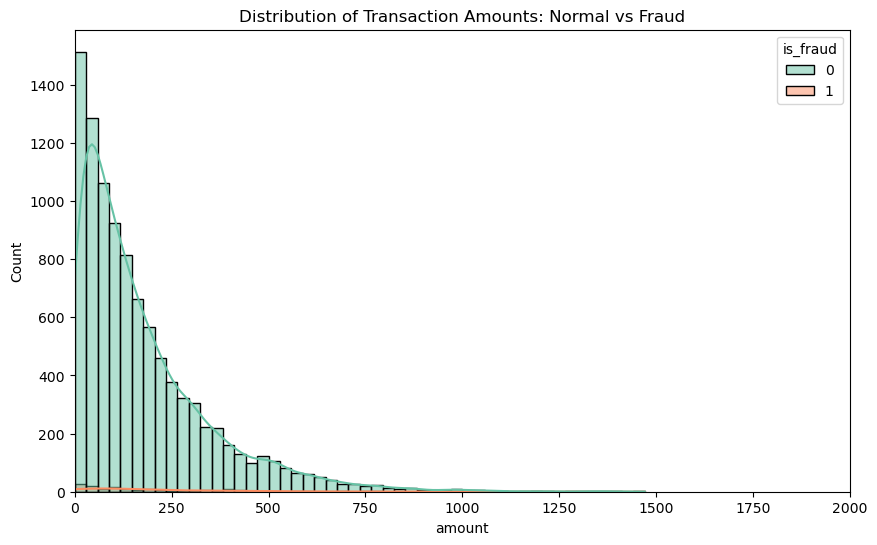

In [4]:
# 1. Distribution of transaction amounts
plt.figure(figsize=(10, 6))

# We use a histogram to show how often certain transaction amounts occur
sns.histplot(data=df, x='amount', hue='is_fraud', bins=50, kde=True, palette='Set2')

plt.title('Distribution of Transaction Amounts: Normal vs Fraud')
plt.xlim(0, 2000) # We zoom in to 0-2000 so the graph is easier to read
plt.show()

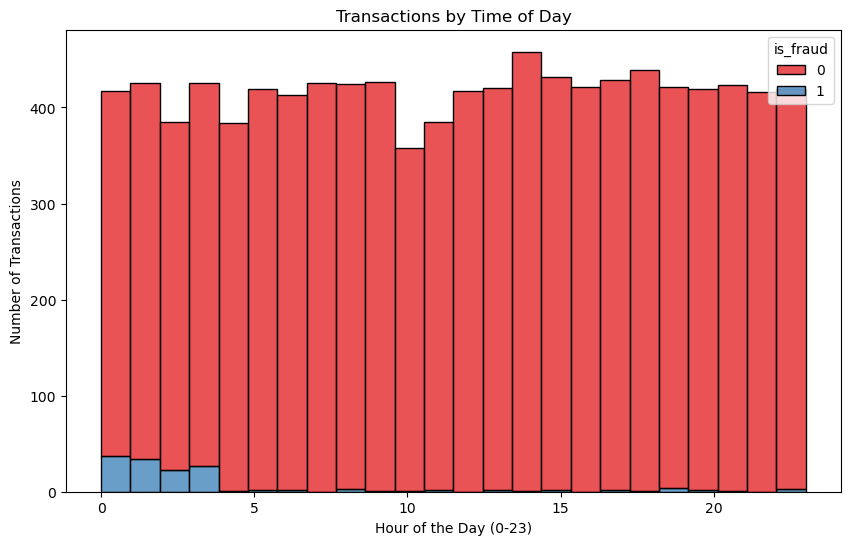

In [5]:
# 2. Time-of-day analysis
plt.figure(figsize=(10, 6))

# A stacked histogram helps us see the proportion of fraud per hour
sns.histplot(data=df, x='transaction_hour', hue='is_fraud', bins=24, multiple="stack", palette='Set1')

plt.title('Transactions by Time of Day')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Transactions')
plt.show()

## Step 3: Why is Standard "Accuracy" Misleading? 
Imagine a dataset with 9,900 normal transactions and 100 fraudulent ones. 

If we create a "lazy" AI model that simply predicts **"Everything is Normal"**, it will be correct 9,900 out of 10,000 times. That's a **99% Accuracy Rate**! 

However, this AI caught **0 criminals**. For a bank, this model is absolutely useless. 

Because of this, we cannot trust "Accuracy". Instead, we rely on:
- **Recall**: Out of all the *actual frauds*, how many did we catch? (Very important for banks).
- **Precision**: Out of all the transactions we *flagged as fraud*, how many were actually fraud? (If this is low, we annoy customers by blocking valid cards).
- **F1-Score**: A combination of both Recall and Precision.

## Step 4: Data Preprocessing
Machine learning models only understand numbers. If we have text data (like `merchant_category` = "Grocery" or "Electronics"), we need to convert it into numbers.

We do this using a technique called **One-Hot Encoding**. It creates a new column for each category, marking it with a `1` or `0`.

In [6]:
# Convert categorical text columns into 1s and 0s
df_encoded = pd.get_dummies(df, columns=['merchant_category'], drop_first=True)

# Separate our "Features" (the clues the AI will use) from our "Target" (what we want to predict)
# X = All columns EXCEPT transaction_id (useless) and is_fraud (our target)
X = df_encoded.drop(['transaction_id', 'is_fraud'], axis=1)

# y = ONLY the target column
y = df_encoded['is_fraud']

## Step 5: Train/Test Split (With Stratification)
We need to hide some data from the model during training so we can test it later. Usually, we split it 80% for training and 20% for testing.

**Important Note:** Because fraud is so rare, if we split randomly, the 20% test set might accidentally end up with 0 fraud cases! To fix this, we use `stratify=y`. This forces Python to ensure both the training and test sets have the exact same percentage of fraud cases.

In [7]:
# Split the data 80% train, 20% test. 'random_state=42' ensures we get the same split every time we run this code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Fraud cases in the Training Set:", sum(y_train))
print("Fraud cases in the Test Set:", sum(y_test))

Fraud cases in the Training Set: 121
Fraud cases in the Test Set: 30


## Step 6: Fixing the Imbalance using SMOTE
Now for the magic trick! We use a technique called **SMOTE** (Synthetic Minority Over-sampling Technique). 

Instead of just duplicating the few fraud cases we have, SMOTE mathematically analyzes the fraud data points and generates **new, synthetic, but highly realistic fraud examples**. This gives our AI enough "bad guys" to study.

*Note: We ONLY apply SMOTE to the training data. The test data must remain untouched and purely real.*

In [8]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Generate the synthetic data!
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Data counts BEFORE SMOTE:")
print(y_train.value_counts())

print("\nData counts AFTER SMOTE:")
print(y_train_smote.value_counts())
# You will see the numbers are now perfectly balanced 50/50!

Data counts BEFORE SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Data counts AFTER SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


## Step 7: Model Training & Evaluation
It's time to train our AI! We'll try two different models to see which is smarter:
1. **Logistic Regression**: A simple, fast, and classic statistical model.
2. **Random Forest**: A powerful algorithm that builds hundreds of "decision trees" and takes a vote.

In [9]:
# We'll create a reusable function so we don't have to copy/paste evaluation code!
def evaluate_model(model, X_test, y_test, model_name):
    # Make predictions (0 or 1)
    y_pred = model.predict(X_test)
    
    # Predict the PROBABILITY of fraud (0.0 to 1.0)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"--- {model_name} Results ---")
    print("Accuracy : {:.4f}".format(accuracy_score(y_test, y_pred)))
    print("Precision: {:.4f} (When it guesses fraud, it is right this % of the time)".format(precision_score(y_test, y_pred)))
    print("Recall   : {:.4f} (It successfully caught this % of ALL actual frauds)".format(recall_score(y_test, y_pred)))
    print("F1-Score : {:.4f}".format(f1_score(y_test, y_pred)))
    print("AUC-ROC  : {:.4f}\n".format(roc_auc_score(y_test, y_prob)))
    
    # Calculate data for the ROC graph
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc_score(y_test, y_prob):.4f})")

--- Logistic Regression Results ---
Accuracy : 0.9250
Precision: 0.1591 (When it guesses fraud, it is right this % of the time)
Recall   : 0.9333 (It successfully caught this % of ALL actual frauds)
F1-Score : 0.2718
AUC-ROC  : 0.9832

--- Random Forest Results ---
Accuracy : 0.9825
Precision: 0.4490 (When it guesses fraud, it is right this % of the time)
Recall   : 0.7333 (It successfully caught this % of ALL actual frauds)
F1-Score : 0.5570
AUC-ROC  : 0.9868



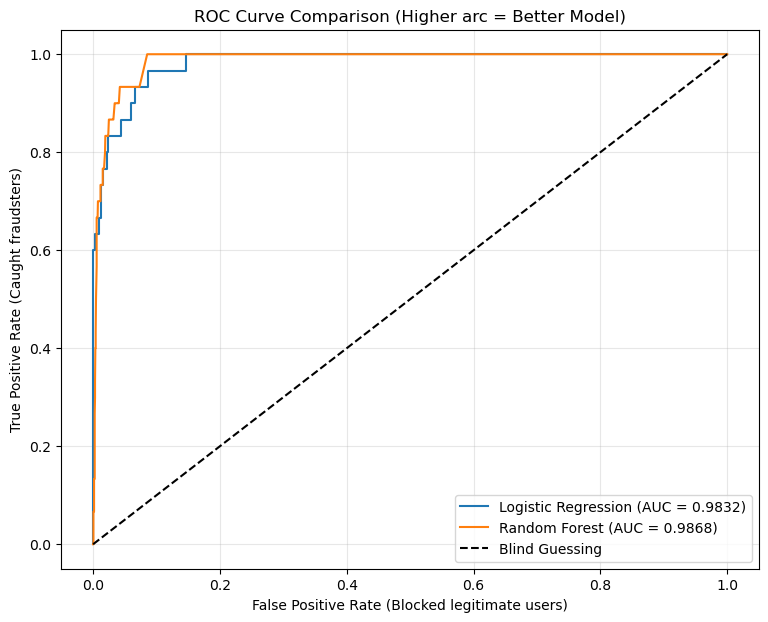

In [10]:
# Set up the graph canvas
plt.figure(figsize=(9, 7))

# --- Model 1: Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote) # Train the model!
evaluate_model(log_reg, X_test, y_test, "Logistic Regression")

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote) # Train the model!
evaluate_model(rf_model, X_test, y_test, "Random Forest")

# --- Finalize the Graph ---
plt.plot([0, 1], [0, 1], 'k--', label='Blind Guessing')
plt.title('ROC Curve Comparison (Higher arc = Better Model)')
plt.xlabel('False Positive Rate (Blocked legitimate users)')
plt.ylabel('True Positive Rate (Caught fraudsters)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 8: What Metric Should We Actually Care About?

In the real world of Fraud Detection, **Recall** is generally considered the most critical metric. 
- **High Recall** means we successfully stop the most fraud (minimizing our financial losses).
- However, if we push Recall *too high*, our **Precision** drops. This means the bank accidentally blocks legitimate customers from buying their groceries (False Positives).

The business has to make a choice: Is it better to lose $500 to a scammer, or anger a rich customer by declining their card? We usually look at the **AUC-ROC Curve** (the graph above) to find the perfect sweet spot!

## Step 9: Inside the AI's Brain (Feature Importance)
Unlike humans, AI can't just explain *why* it thought something was fraud. However, with models like the Random Forest, we can extract **Feature Importance**. This tells us which "clues" the AI relied on the most when making its decisions.

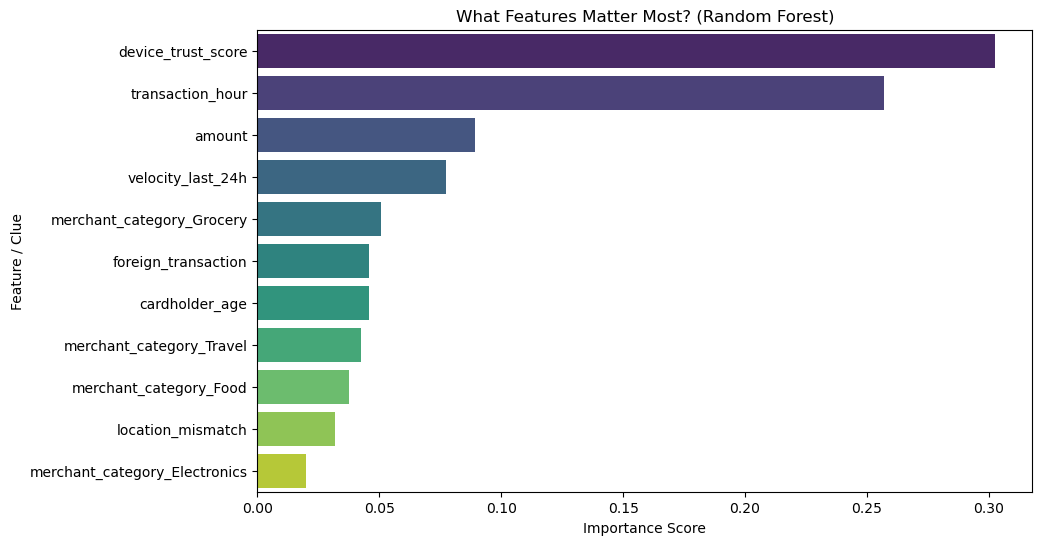

In [11]:
# Extract the importance of each feature from our Random Forest model
feature_importances = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model.feature_importances_
})

# Sort from most important to least important
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot it out visually
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('What Features Matter Most? (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature / Clue')
plt.show()

## Step 10: Thinking Like an Engineer (Scalability)

We successfully built a model! But let's pretend you are hired by Visa or Mastercard. You have to process **1 Million transactions per hour**. How does this notebook change in the real world?

1. **Faster AI Models**: Random Forest is powerful but can be slow to predict in real-time. Engineers often switch to high-speed frameworks like **XGBoost** or **LightGBM**, or convert the models to `C++`.
2. **Streaming Architecture**: We wouldn't load a CSV file using Pandas. We would connect our model to a live data stream like **Apache Kafka**.
3. **Lightning Fast Databases**: Our model uses features like `velocity_last_24h` (how many times a card was swiped today). To calculate this instantly for a million people, we need hyper-fast databases like **Redis**.
4. **API Endpoints**: We would wrap our final model in a web service using **FastAPI** or AWS SageMaker. When a user swipes a card at a store, the terminal sends a tiny packet of data to our API, and the API replies `Approve` or `Decline` in under 50 milliseconds!